# 01 — Data Acquisition
## Tariff Shock Tracker: US–China Equity Analysis

**Research Question**: How did the Biden administration's May 14, 2024 
tariff announcement (100% on Chinese EVs, 50% on solar panels, 25% on 
lithium batteries) affect US and Chinese stock prices in tariff-sensitive 
sectors?

**Target Audience**: Finance students and retail investors seeking 
evidence-based analysis of policy shocks on equity markets.

**Data Sources**:
- US stocks: CRSP Daily Stock File (`crsp.dsf`) via WRDS
- Chinese stocks: CSMAR Daily Return Table (`csmar.trd_dalyr`) via WRDS
- Market benchmarks: CRSP Daily Index (`crsp.dsi`) + CSMAR Index (`csmar.trd_index`)

**Author**: xinyan.Wang2403
**Date**: April 2026  
**Module**: ACC102, XJTLU


# =============================================================
# Setup: Import libraries and establish WRDS connection
# =============================================================
import wrds
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import os
import warnings
warnings.filterwarnings('ignore')

# Establish WRDS connection
conn = wrds.Connection()
print("✅ Connected to WRDS")
print(f"   Libraries available: {len(conn.list_libraries())}")


In [1]:
import wrds
conn = wrds.Connection()

Enter your WRDS username [macbookair]: galaxy
Enter your password: ········


WRDS recommends setting up a .pgpass file.


Create .pgpass file now [y/n]?:  y


Created .pgpass file successfully.
You can create this file yourself at any time with the create_pgpass_file() function.
Loading library list...
Done


## 1. Stock Universe & Event Definition

### Event Date
**May 14, 2024** — Biden administration announces major tariff increases 
on Chinese imports: EVs (25% → 100%), solar panels (25% → 50%), 
lithium batteries (7.5% → 25%), semiconductors (25% → 50%).

### Stock Selection Rationale
We select 5 US and 5 Chinese stocks in **tariff-sensitive sectors**:

| Country | Ticker/Code | Company | Sector | Expected Impact |
|---|---|---|---|---|
| 🇺🇸 US | AAPL | Apple | Consumer Electronics | ↓ Supply chain cost |
| 🇺🇸 US | NVDA | NVIDIA | Semiconductors | ↓ Export controls |
| 🇺🇸 US | TSLA | Tesla | Automotive | ↑ Reduced competition |
| 🇺🇸 US | GM | General Motors | Automotive | ↓ China market |
| 🇺🇸 US | WMT | Walmart | Retail | ↓ Import costs |
| 🇨🇳 CN | 300750 | CATL 宁德时代 | Batteries | ↓ Direct tariff target |
| 🇨🇳 CN | 002594 | BYD 比亚迪 | EV | ↓ Direct tariff target |
| 🇨🇳 CN | 000333 | Midea 美的 | Appliances | ↓ Export costs |
| 🇨🇳 CN | 002475 | Luxshare 立讯 | Supply Chain | ↓ Apple dependency |
| 🇨🇳 CN | 600519 | Kweichow Moutai 茅台 | Consumer (Domestic) | ~ Control group |

**Key insight**: Kweichow Moutai serves as a **control group** — as a 
domestically-focused company with minimal export exposure, it should 
show minimal abnormal returns around the tariff event if our methodology 
is sound.


---
## 2. US Stock Data (CRSP)

We query `crsp.dsf` (Daily Stock File) — the most comprehensive 
source of US equity data, with records dating back to 1925.

**Key variables retrieved:**
- `prc`: Closing price (negative values indicate bid-ask midpoint estimates — we take the absolute value)
- `ret`: **Daily holding period return** (dividend-adjusted, split-adjusted) — this is our primary variable for the event study
- `retx`: Return excluding dividends — used as a robustness check
- `vol`: Trading volume
- `shrout`: Shares outstanding (used to calculate market capitalisation)

**CRSP permno identifiers** (permanent stock numbers, more stable than tickers):
AAPL=14593, NVDA=86580, TSLA=93436, GM=12369, WMT=55976


In [3]:
#  All 5 stocks with verified permnos

us_permnos = {
    14593: 'AAPL',
    86580: 'NVDA',   
    93436: 'TSLA',
    12369: 'GM',
    55976: 'WMT'
}

permno_str = ', '.join(str(p) for p in us_permnos.keys())

us_sql = f"""
    SELECT date, permno, prc, ret, vol, shrout, retx
    FROM crsp.dsf
    WHERE date BETWEEN '2023-10-01' AND '2024-08-31'
    AND permno IN ({permno_str})
    ORDER BY permno, date
"""

print("📥 Downloading US stock data from CRSP...")
us_df = conn.raw_sql(us_sql, date_cols=['date'])
us_df['ticker'] = us_df['permno'].map(us_permnos)
us_df['prc'] = us_df['prc'].abs()

print(f"✅ Downloaded {len(us_df):,} rows")
print(f"   Stocks: {sorted(us_df['ticker'].unique())}")
print(f"\nRows per stock:")
print(us_df.groupby('ticker').size())


📥 Downloading US stock data from CRSP...
✅ Downloaded 1,155 rows
   Stocks: ['AAPL', 'GM', 'NVDA', 'TSLA', 'WMT']

Rows per stock:
ticker
AAPL    231
GM      231
NVDA    231
TSLA    231
WMT     231
dtype: int64


---
## 3. US Market Benchmark (CRSP Daily Index)

We retrieve the **S&P 500 return** (`sprtrn`) from `crsp.dsi` as the 
market benchmark for the US event study.

In the market model framework:
$$R_{i,t} = \alpha_i + \beta_i \cdot R_{m,t} + \varepsilon_{i,t}$$

The S&P 500 serves as $R_{m,t}$ — the expected market-wide return 
that each stock "should" track under normal conditions.

We also retrieve `vwretd` (value-weighted return including dividends) 
as an alternative benchmark for robustness testing.


In [4]:
 # S&P 500 
mkt_sql = """
    SELECT date, vwretd, ewretd, sprtrn
    FROM crsp.dsi
    WHERE date BETWEEN '2023-10-01' AND '2024-08-31'
    ORDER BY date
"""

print("📥 Downloading S&P 500 index from CRSP...")
mkt_df = conn.raw_sql(mkt_sql, date_cols=['date'])
print(f"✅ Downloaded {len(mkt_df):,} trading days")
print(mkt_df.head(3))


📥 Downloading S&P 500 index from CRSP...
✅ Downloaded 231 trading days
        date    vwretd    ewretd    sprtrn
0 2023-10-02 -0.003498 -0.011886  0.000079
1 2023-10-03 -0.014349 -0.015225 -0.013744
2 2023-10-04  0.007075  0.001074   0.00811


---
## 4. Chinese Stock Data (CSMAR)

We query `csmar.trd_dalyr` (Daily Return file) from the **China Stock 
Market & Accounting Research (CSMAR)** database.

**Key variables retrieved:**
- `clsprc`: Daily closing price
- `dretwd`: **Daily return with cash dividend reinvested** — equivalent to CRSP's `ret`, our primary return variable
- `dsmvtll`: Total market value (capitalisation)
- `dnshrtrd`: Number of shares traded (volume)

**Stock codes** (6-digit A-share codes):
CATL=300750, BYD=002594, Midea=000333, Luxshare=002475, Moutai=600519

**Note on Chinese market trading**: A-shares are subject to a ±10% 
daily price limit (涨跌停). Days showing exactly 0.0 return may 
indicate a limit-hit day or non-trading day — we retain these 
observations as they reflect genuine market conditions.


In [5]:
#  Download Chinese stock data from CSMAR

cn_stocks = {
    '300750': '宁德时代 CATL',      
    '002594': '比亚迪 BYD',          
    '000333': '美的集团 Midea',      
    '002475': '立讯精密 Luxshare',   
    '600519': '贵州茅台 Kweichow',  
}

stkcd_list = "', '".join(cn_stocks.keys())

cn_sql = f"""
    SELECT trddt, stkcd, clsprc, dretwd, dsmvtll, dnshrtrd
    FROM csmar.trd_dalyr
    WHERE trddt BETWEEN '2023-10-01' AND '2024-08-31'
    AND stkcd IN ('{stkcd_list}')
    ORDER BY stkcd, trddt
"""

print("📥 Downloading Chinese stock data from CSMAR...")
cn_df = conn.raw_sql(cn_sql, date_cols=['trddt'])


cn_df['company'] = cn_df['stkcd'].map(cn_stocks)


cn_df = cn_df.rename(columns={
    'trddt': 'date',
    'clsprc': 'prc',
    'dretwd': 'ret',
    'dsmvtll': 'mktcap',
    'dnshrtrd': 'vol'
})

print(f"✅ Downloaded {len(cn_df):,} rows")
print(f"   Date range: {cn_df['date'].min().date()} → {cn_df['date'].max().date()}")
print(f"\nRows per stock:")
print(cn_df.groupby(['stkcd', 'company']).size())
print(f"\nFirst 3 rows:")
cn_df.head(3)


📥 Downloading Chinese stock data from CSMAR...
✅ Downloaded 1,110 rows
   Date range: 2023-10-09 → 2024-08-30

Rows per stock:
stkcd   company      
000333  美的集团 Midea       222
002475  立讯精密 Luxshare    222
002594  比亚迪 BYD          222
300750  宁德时代 CATL        222
600519  贵州茅台 Kweichow    222
dtype: int64

First 3 rows:


,date,stkcd,prc,ret,mktcap,vol,company
0,2023-10-09,000333,55.76,0.005047,391601640.87,28659545.0,美的集团 Midea
1,2023-10-10,000333,54.77,-0.017755,384648885.77,21499637.0,美的集团 Midea
2,2023-10-11,000333,54.77,0.0,384648885.77,20418379.0,美的集团 Midea


In [6]:
cn_idx_sql = """
    SELECT *
    FROM csmar.trd_index
    WHERE trddt BETWEEN '2023-10-01' AND '2024-08-31'
    LIMIT 5
"""

sample = conn.raw_sql(cn_idx_sql)
print("Sample from trd_index:")
print(sample)
print("\nColumns:", list(sample.columns))


Sample from trd_index:
  indexcd  daywk  opnindex   hiindex   loindex  clsindex  retindex trddt_str  \
0  000001      1    3100.0   3103.36  3072.642  3096.922 -0.004357  20231009   
1  000002      1  3250.143  3253.766  3221.484  3247.015 -0.004329  20231009   
2  000003      1   235.458   235.458   230.644   231.414 -0.020366  20231009   
3  000010      1  7962.023  7982.122  7891.661  7966.148 -0.003212  20231009   
4  000020      1  1217.803  1217.803  1208.237  1212.513 -0.005484  20231009   

        trddt  
0  2023-10-09  
1  2023-10-09  
2  2023-10-09  
3  2023-10-09  
4  2023-10-09  

Columns: ['indexcd', 'daywk', 'opnindex', 'hiindex', 'loindex', 'clsindex', 'retindex', 'trddt_str', 'trddt']


---
## 4. Chinese Stock Data (CSMAR)

We query `csmar.trd_dalyr` (Daily Return file) from the **China Stock 
Market & Accounting Research (CSMAR)** database.

**Key variables retrieved:**
- `clsprc`: Daily closing price
- `dretwd`: **Daily return with cash dividend reinvested** — equivalent to CRSP's `ret`, our primary return variable
- `dsmvtll`: Total market value (capitalisation)
- `dnshrtrd`: Number of shares traded (volume)

**Stock codes** (6-digit A-share codes):
CATL=300750, BYD=002594, Midea=000333, Luxshare=002475, Moutai=600519

**Note on Chinese market trading**: A-shares are subject to a ±10% 
daily price limit (涨跌停). Days showing exactly 0.0 return may 
indicate a limit-hit day or non-trading day — we retain these 
observations as they reflect genuine market conditions.


In [7]:
# Download CSI 300 (沪深300) as China market benchmark


cn_mkt_sql = """
    SELECT trddt, indexcd, clsindex, retindex
    FROM csmar.trd_index
    WHERE trddt BETWEEN '2023-10-01' AND '2024-08-31'
    AND indexcd IN ('000300', '000001')
    ORDER BY indexcd, trddt
"""

print("📥 Downloading China market indices from CSMAR...")
cn_mkt_df = conn.raw_sql(cn_mkt_sql, date_cols=['trddt'])
cn_mkt_df = cn_mkt_df.rename(columns={'trddt': 'date'})

print(f"✅ Downloaded {len(cn_mkt_df):,} rows")
print(f"\nRows per index:")
print(cn_mkt_df.groupby('indexcd').size())
print(f"\nSample:")
print(cn_mkt_df.head(3))

📥 Downloading China market indices from CSMAR...
✅ Downloaded 444 rows

Rows per index:
indexcd
000001    222
000300    222
dtype: int64

Sample:
        date indexcd  clsindex  retindex
0 2023-10-09  000001  3096.922 -0.004357
1 2023-10-10  000001  3075.236 -0.007002
2 2023-10-11  000001  3078.956   0.00121


In [10]:
import os

save_dir = os.path.expanduser(
    '~/Desktop/tariff-shock-tracker/data/raw')
os.makedirs(save_dir, exist_ok=True)

us_df.to_csv(f'{save_dir}/us_stocks_crsp.csv', index=False)
mkt_df.to_csv(f'{save_dir}/us_market_index_crsp.csv', index=False)
cn_df.to_csv(f'{save_dir}/cn_stocks_csmar.csv', index=False)
cn_mkt_df.to_csv(f'{save_dir}/cn_market_index_csmar.csv', index=False)

print("✅ All 4 files saved:")
print(f"   us_stocks_crsp.csv         {us_df.shape}")
print(f"   us_market_index_crsp.csv   {mkt_df.shape}")
print(f"   cn_stocks_csmar.csv        {cn_df.shape}")
print(f"   cn_market_index_csmar.csv  {cn_mkt_df.shape}")


✅ All 4 files saved:
   us_stocks_crsp.csv         (1155, 8)
   us_market_index_crsp.csv   (231, 4)
   cn_stocks_csmar.csv        (1110, 7)
   cn_market_index_csmar.csv  (444, 4)


---
## 5. Preliminary Visualisation: Indexed Price Performance

Before conducting the formal event study, we visualise the **indexed 
price performance** of all 10 stocks from October 2023 onwards.

**Methodology**: Each stock's price is indexed to 100 on its first 
trading day in the sample. This normalisation allows direct comparison 
across stocks with very different absolute price levels (e.g. Moutai 
at ¥1,700 vs BYD at ¥200).

**What to look for**:
- Do US and Chinese stocks in the same sector react similarly or differently?
- Does the reaction appear **immediately** on May 14, or over several days?
- Does Kweichow Moutai (control group) show minimal reaction compared to the EV/battery stocks?

> **Note**: This visualisation shows raw price performance, not 
> abnormal returns. The formal event study (Notebook 02) will isolate 
> the **market-adjusted** component of the price movement.


✅ Saved cn_market_index_csmar.csv  (444, 4)


/var/folders/n6/9p8dkp0x2fz517dtfqr_x4vm0000gn/T/ipykernel_44858/1032753888.py:134: UserWarning: Glyph 127482 (\N{REGIONAL INDICATOR SYMBOL LETTER U}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/n6/9p8dkp0x2fz517dtfqr_x4vm0000gn/T/ipykernel_44858/1032753888.py:134: UserWarning: Glyph 127480 (\N{REGIONAL INDICATOR SYMBOL LETTER S}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/n6/9p8dkp0x2fz517dtfqr_x4vm0000gn/T/ipykernel_44858/1032753888.py:134: UserWarning: Glyph 127464 (\N{REGIONAL INDICATOR SYMBOL LETTER C}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/n6/9p8dkp0x2fz517dtfqr_x4vm0000gn/T/ipykernel_44858/1032753888.py:134: UserWarning: Glyph 127475 (\N{REGIONAL INDICATOR SYMBOL LETTER N}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/n6/9p8dkp0x2fz517dtfqr_x4vm0000gn/T/ipykernel_44858/1032753888.py:134: UserWarning: Glyph 32654 (\N{CJK UNIFIED IDEOGRAPH-7F8E}) missing from font(s) DejaVu Sans.


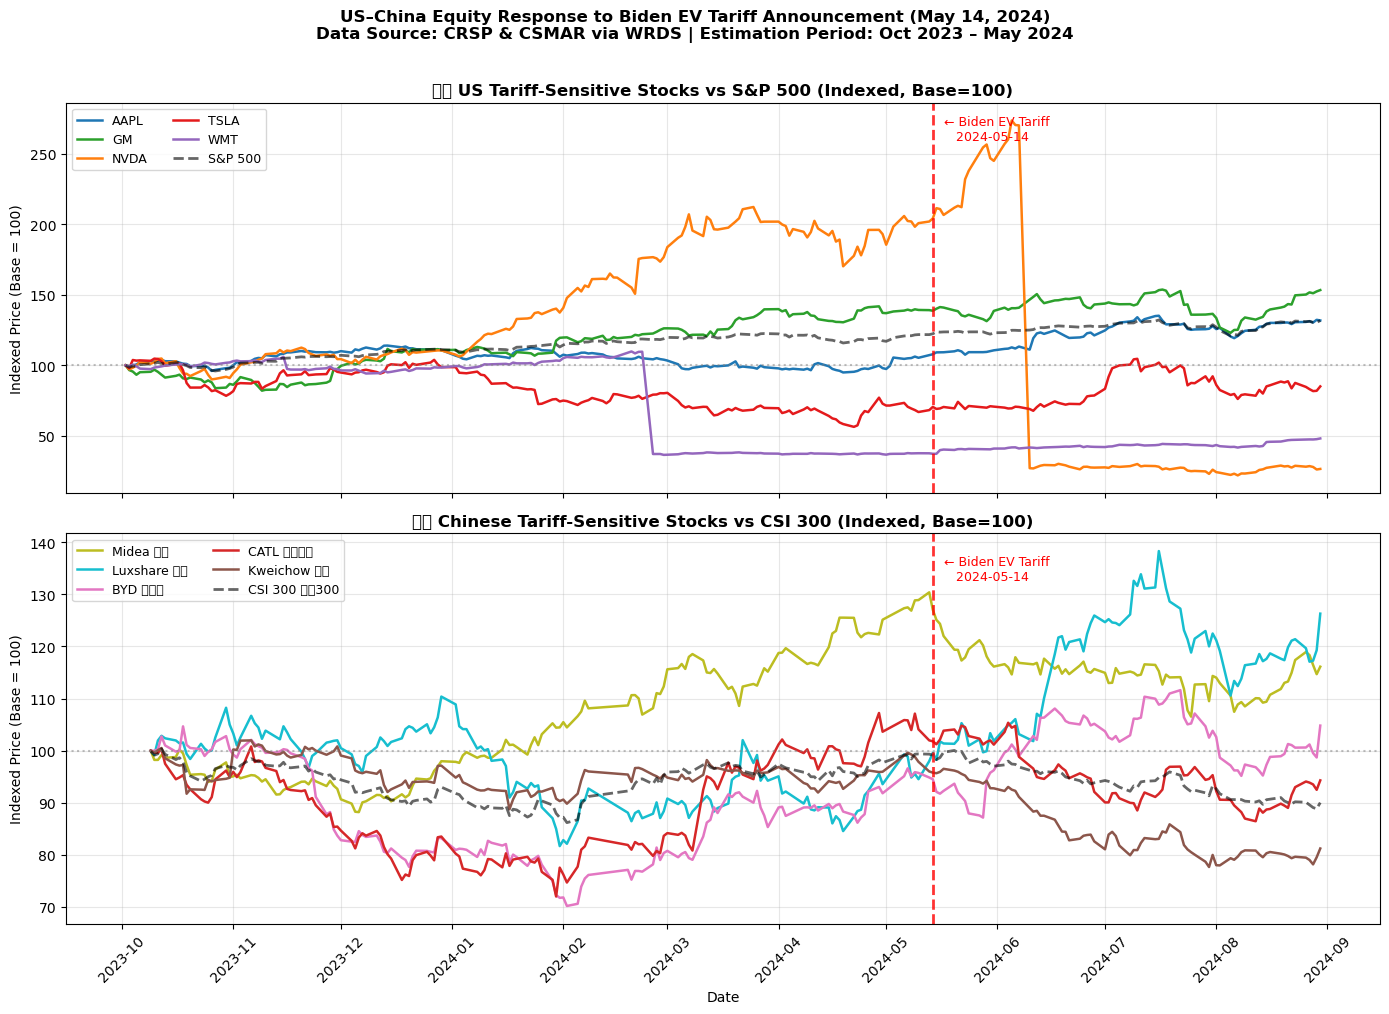

✅ Chart saved!


In [12]:
#  Save CN market index + Draw the BIG comparison chart

import os
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd


save_dir = os.path.expanduser(
    '~/Desktop/tariff-shock-tracker/data/raw')
cn_mkt_df.to_csv(f'{save_dir}/cn_market_index_csmar.csv', 
                  index=False)
print(f"✅ Saved cn_market_index_csmar.csv  {cn_mkt_df.shape}")


fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), 
                                 sharex=True)

EVENT_DATE = pd.Timestamp('2024-05-14')


us_colors = {
    'AAPL': '#1f77b4',
    'NVDA': '#ff7f0e',
    'TSLA': '#e41a1c',
    'GM':   '#2ca02c',
    'WMT':  '#9467bd'
}

for ticker, grp in us_df.groupby('ticker'):
    grp = grp.sort_values('date').copy()
    base = grp['prc'].iloc[0]
    grp['idx'] = grp['prc'] / base * 100
    ax1.plot(grp['date'], grp['idx'],
             label=ticker,
             color=us_colors[ticker],
             linewidth=1.8)


sp500 = mkt_df.sort_values('date').copy()
sp500['cum_ret'] = (1 + sp500['sprtrn']).cumprod() * 100
ax1.plot(sp500['date'], sp500['cum_ret'],
         label='S&P 500', color='black',
         linewidth=2, linestyle='--', alpha=0.6)


ax1.axvline(EVENT_DATE, color='red',
            linestyle='--', linewidth=2, alpha=0.8)
ax1.text(EVENT_DATE + pd.Timedelta(days=3),
         ax1.get_ylim()[1] * 0.97,
         '← Biden EV Tariff\n   2024-05-14',
         fontsize=9, color='red', va='top')

ax1.set_title(
    '🇺🇸 US Tariff-Sensitive Stocks vs S&P 500 '
    '(Indexed, Base=100)',
    fontsize=12, fontweight='bold')
ax1.set_ylabel('Indexed Price (Base = 100)', fontsize=10)
ax1.legend(loc='upper left', fontsize=9, ncol=2)
ax1.grid(True, alpha=0.3)
ax1.axhline(100, color='gray', linestyle=':', alpha=0.5)

cn_colors = {
    '300750': '#d62728',
    '002594': '#e377c2',
    '000333': '#bcbd22',
    '002475': '#17becf',
    '600519': '#8c564b'
}
cn_labels = {
    '300750': 'CATL 宁德时代',
    '002594': 'BYD 比亚迪',
    '000333': 'Midea 美的',
    '002475': 'Luxshare 立讯',
    '600519': 'Kweichow 茅台'
}

for stkcd, grp in cn_df.groupby('stkcd'):
    grp = grp.sort_values('date').dropna(
        subset=['prc']).copy()
    if len(grp) == 0 or grp['prc'].iloc[0] == 0:
        continue
    base = grp['prc'].iloc[0]
    grp['idx'] = grp['prc'] / base * 100
    ax2.plot(grp['date'], grp['idx'],
             label=cn_labels.get(stkcd, stkcd),
             color=cn_colors.get(stkcd, 'gray'),
             linewidth=1.8)


csi300 = cn_mkt_df[
    cn_mkt_df['indexcd'] == '000300'].sort_values(
    'date').copy()
csi300 = csi300.dropna(subset=['retindex'])
csi300['cum_ret'] = (
    1 + csi300['retindex']).cumprod() * 100
ax2.plot(csi300['date'], csi300['cum_ret'],
         label='CSI 300 沪深300',
         color='black', linewidth=2,
         linestyle='--', alpha=0.6)


ax2.axvline(EVENT_DATE, color='red',
            linestyle='--', linewidth=2, alpha=0.8)
ax2.text(EVENT_DATE + pd.Timedelta(days=3),
         ax2.get_ylim()[1] * 0.97,
         '← Biden EV Tariff\n   2024-05-14',
         fontsize=9, color='red', va='top')

ax2.set_title(
    '🇨🇳 Chinese Tariff-Sensitive Stocks vs CSI 300 '
    '(Indexed, Base=100)',
    fontsize=12, fontweight='bold')
ax2.set_ylabel('Indexed Price (Base = 100)', fontsize=10)
ax2.set_xlabel('Date', fontsize=10)
ax2.legend(loc='upper left', fontsize=9, ncol=2)
ax2.grid(True, alpha=0.3)
ax2.axhline(100, color='gray', linestyle=':', alpha=0.5)


ax2.xaxis.set_major_formatter(
    mdates.DateFormatter('%Y-%m'))
ax2.xaxis.set_major_locator(
    mdates.MonthLocator(interval=1))
plt.xticks(rotation=45)

plt.suptitle(
    'US–China Equity Response to Biden EV Tariff '
    'Announcement (May 14, 2024)\n'
    'Data Source: CRSP & CSMAR via WRDS | '
    'Estimation Period: Oct 2023 – May 2024',
    fontsize=12, fontweight='bold', y=1.01)

plt.tight_layout()


img_dir = os.path.expanduser(
    '~/Desktop/tariff-shock-tracker/assets/screenshots')
os.makedirs(img_dir, exist_ok=True)
plt.savefig(f'{img_dir}/us_cn_comparison.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart saved!")
